In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/INDENG 290') # customize this line to your working directory

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from shapely.geometry import Point
from google.colab import files
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from scipy.spatial import distance
from shapely.geometry import Point, Polygon
from sklearn.neighbors import KernelDensity
import statsmodels.api as sm
from scipy.spatial import cKDTree
import warnings

In [3]:
df = pd.read_csv('processed_crash_data.csv')

<ipython-input-3-60e4ecb341f0>:1: DtypeWarning: Columns (3,15,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processed_crash_data.csv')


In [6]:
df

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,lighting_condition,road_condition_simple,environmental_risk_score,weather_1_simple,weather_2_simple,road_surface_condition,road_cond_1_simple,road_cond_2_simple,road_condition_combined,road_condition
0,40386,27145000.0,7847000.0,150419581,37.760300,-122.466325,SFPD-CROSSROADS,CITY STREET,2015-05-14 13:15:00,2015-05-14,...,Good,Unknown,1,Good,Unknown,Good,Unknown,Unknown,Unknown,Unknown
1,91730,24911000.0,3432000.0,240648080,37.790404,-122.406851,SFPD-INTERIM DB,CITY STREET,2024-10-15 00:29:00,2024-10-15,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
2,5788,33284000.0,2800202.0,150638797,37.742285,-122.405916,SFPD-CROSSROADS,CITY STREET,2015-07-22 21:30:00,2015-07-22,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
3,10457,25631000.0,NaN,3843463,37.755029,-122.425457,SFPD-CROSSROADS,CITY STREET,2008-07-27 21:00:00,2008-07-27,...,Moderate,Unknown,1,Good,Unknown,Good,Good,Unknown,Unknown,Good
4,92561,21898000.0,NaN,230757362,37.748773,-122.422571,SFPD-INTERIM DB,CITY STREET,2023-10-22 15:51:00,2023-10-22,...,Good,Unknown,5,Bad,Unknown,Poor,Unknown,Unknown,Poor,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61695,14294,24350000.0,NaN,130084756,37.772649,-122.415002,SFPD-CROSSROADS,CITY STREET,2013-01-29 08:20:00,2013-01-29,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61696,43318,27230000.0,6056201.0,150044774,37.781258,-122.458857,SFPD-CROSSROADS,CITY STREET,2015-01-15 13:39:00,2015-01-15,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61697,23907,24590000.0,NaN,140757357,37.785030,-122.400468,SFPD-CROSSROADS,CITY STREET,2014-09-08 18:00:00,2014-09-08,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good
61698,3235,33269000.0,NaN,150766235,37.734014,-122.390968,SFPD-CROSSROADS,CITY STREET,2015-09-01 09:35:00,2015-09-01,...,Good,Unknown,0,Good,Unknown,Good,Good,Unknown,Unknown,Good


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61700 entries, 0 to 61699
Data columns (total 99 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   unique_id                     61700 non-null  int64  
 1   cnn_intrsctn_fkey             61672 non-null  float64
 2   cnn_sgmt_fkey                 27555 non-null  float64
 3   case_id_pkey                  61700 non-null  object 
 4   tb_latitude                   61527 non-null  float64
 5   tb_longitude                  61527 non-null  float64
 6   geocode_source                61700 non-null  object 
 7   geocode_location              61700 non-null  object 
 8   collision_datetime            61700 non-null  object 
 9   collision_date                61700 non-null  object 
 10  collision_time                61700 non-null  object 
 11  accident_year                 61700 non-null  int64  
 12  month                         61700 non-null  int64  
 13  d

In [8]:
# test = df.head(10)
# test.to_csv('test.csv')

In [9]:
def create_grid(accident_data, base_grid_size=200, adaptive=True, density_threshold=0.6,
                fine_grid_factor=0.4, coarse_grid_factor=1.5, min_grid_size=100):
    """
    创建空间网格并计算每个网格中的事故数量，支持可变网格大小，优化为更细粒度分析

    参数:
    accident_data: 预处理后的事故数据
    base_grid_size: 基本网格大小(米)，默认200米更适合细粒度分析
    adaptive: 是否使用自适应网格大小
    density_threshold: 高密度区域的阈值（用于自适应网格），降低为0.6可识别更多热点
    fine_grid_factor: 高密度区域网格大小的缩小因子
    coarse_grid_factor: 低密度区域网格大小的放大因子
    min_grid_size: 最小网格大小(米)

    返回:
    grid_data: 网格数据DataFrame
    accident_data_copy: 添加了网格信息的事故数据副本
    """
    print("正在创建细粒度空间网格...")

    # 确定研究区域的边界
    lon_min, lon_max = accident_data['tb_longitude'].min(), accident_data['tb_longitude'].max()
    lat_min, lat_max = accident_data['tb_latitude'].min(), accident_data['tb_latitude'].max()

    # 基本网格大小转换为经纬度单位
    base_lon_grid_size = base_grid_size / 111000  # 经度1度约等于111km
    # 纬度1度的实际距离随纬度变化，在旧金山（约北纬37.8度）调整系数
    lat_adjust = np.cos(np.radians(37.8))
    base_lat_grid_size = base_grid_size / (111000 * lat_adjust)

    # 创建事故数据副本
    accident_data_copy = accident_data.copy()

    if not adaptive:
        # 使用固定网格大小
        lon_bins = np.arange(lon_min, lon_max + base_lon_grid_size, base_lon_grid_size)
        lat_bins = np.arange(lat_min, lat_max + base_lat_grid_size, base_lat_grid_size)
    else:
        # 创建初始分析用的网格 - 使用较大的网格进行密度分析
        analysis_grid_size = base_grid_size * 2  # 用于分析的粗网格大小
        analysis_lon_grid_size = analysis_grid_size / 111000
        analysis_lat_grid_size = analysis_grid_size / (111000 * lat_adjust)

        analysis_lon_bins = np.arange(lon_min, lon_max + analysis_lon_grid_size, analysis_lon_grid_size)
        analysis_lat_bins = np.arange(lat_min, lat_max + analysis_lat_grid_size, analysis_lat_grid_size)

        # 为每个事故分配到分析网格
        accident_data_copy['analysis_lon'] = pd.cut(accident_data_copy['tb_longitude'],
                                                 bins=analysis_lon_bins,
                                                 labels=range(len(analysis_lon_bins)-1))
        accident_data_copy['analysis_lat'] = pd.cut(accident_data_copy['tb_latitude'],
                                                 bins=analysis_lat_bins,
                                                 labels=range(len(analysis_lat_bins)-1))

        # 处理可能的NaN值
        accident_data_copy = accident_data_copy.dropna(subset=['analysis_lon', 'analysis_lat'])

        # 创建分析网格ID
        accident_data_copy['analysis_grid'] = accident_data_copy['analysis_lon'].astype(str) + '_' + accident_data_copy['analysis_lat'].astype(str)

        # 计算每个网格的事故数
        grid_counts = accident_data_copy['analysis_grid'].value_counts()

        # 计算每个网格的面积（平方米）- 用于计算事故密度
        analysis_grid_area = analysis_grid_size * analysis_grid_size

        # 计算每个网格的事故密度（每平方公里）
        grid_densities = grid_counts / (analysis_grid_area / 1000000)

        # 确定密度阈值，区分高、中、低密度区域
        high_density_threshold = grid_densities.quantile(density_threshold)
        low_density_threshold = grid_densities.quantile(0.25)  # 低密度区域阈值

        # 根据密度分类每个网格
        high_density_grids = set(grid_densities[grid_densities >= high_density_threshold].index)
        low_density_grids = set(grid_densities[grid_densities <= low_density_threshold].index)
        medium_density_grids = set(grid_densities.index) - high_density_grids - low_density_grids

        print(f"密度分析结果:")
        print(f"  高密度区域: {len(high_density_grids)} 个网格")
        print(f"  中密度区域: {len(medium_density_grids)} 个网格")
        print(f"  低密度区域: {len(low_density_grids)} 个网格")

        # 为不同密度区域分配不同的网格大小
        fine_grid_size = max(base_grid_size * fine_grid_factor, min_grid_size)  # 高密度区域网格大小
        medium_grid_size = base_grid_size  # 中密度区域网格大小
        coarse_grid_size = base_grid_size * coarse_grid_factor  # 低密度区域网格大小

        # 转换为经纬度单位
        fine_lon_grid_size = fine_grid_size / 111000
        fine_lat_grid_size = fine_grid_size / (111000 * lat_adjust)

        medium_lon_grid_size = medium_grid_size / 111000
        medium_lat_grid_size = medium_grid_size / (111000 * lat_adjust)

        coarse_lon_grid_size = coarse_grid_size / 111000
        coarse_lat_grid_size = coarse_grid_size / (111000 * lat_adjust)

        # 为每个分析网格分配最终的网格大小
        grid_sizes = {}
        for grid_id in grid_densities.index:
            if grid_id in high_density_grids:
                grid_sizes[grid_id] = (fine_lon_grid_size, fine_lat_grid_size)
            elif grid_id in low_density_grids:
                grid_sizes[grid_id] = (coarse_lon_grid_size, coarse_lat_grid_size)
            else:
                grid_sizes[grid_id] = (medium_lon_grid_size, medium_lat_grid_size)

        # 创建最终的网格边界
        lon_bins = [lon_min]
        lat_bins = [lat_min]

        # 为分析网格中的每个网格创建细分网格
        for i in range(len(analysis_lon_bins) - 1):
            start_lon = analysis_lon_bins[i]
            end_lon = analysis_lon_bins[i+1]

            for j in range(len(analysis_lat_bins) - 1):
                grid_id = f"{i}_{j}"

                if grid_id in grid_sizes:
                    lon_size, lat_size = grid_sizes[grid_id]

                    # 经度方向划分
                    current_lon = start_lon
                    while current_lon < end_lon:
                        if current_lon not in lon_bins:
                            lon_bins.append(current_lon)
                        current_lon += lon_size

                    # 纬度方向划分
                    current_lat = analysis_lat_bins[j]
                    while current_lat < analysis_lat_bins[j+1]:
                        if current_lat not in lat_bins:
                            lat_bins.append(current_lat)
                        current_lat += lat_size

        # 确保包含边界
        if lon_bins[-1] < lon_max:
            lon_bins.append(lon_max)
        if lat_bins[-1] < lat_max:
            lat_bins.append(lat_max)

        # 排序并去重
        lon_bins = sorted(list(set(lon_bins)))
        lat_bins = sorted(list(set(lat_bins)))

    # 为每个事故分配到最终网格
    accident_data_copy['grid_lon'] = pd.cut(accident_data_copy['tb_longitude'],
                                         bins=lon_bins,
                                         labels=range(len(lon_bins)-1))
    accident_data_copy['grid_lat'] = pd.cut(accident_data_copy['tb_latitude'],
                                         bins=lat_bins,
                                         labels=range(len(lat_bins)-1))

    # 处理可能的NaN值
    accident_data_copy = accident_data_copy.dropna(subset=['grid_lon', 'grid_lat'])

    # 转换网格索引为整数
    accident_data_copy['grid_lon'] = accident_data_copy['grid_lon'].astype('int')
    accident_data_copy['grid_lat'] = accident_data_copy['grid_lat'].astype('int')

    # 创建网格唯一标识
    accident_data_copy['grid_id'] = accident_data_copy['grid_lon'].astype(str) + '_' + accident_data_copy['grid_lat'].astype(str)

    # 为每个网格计数
    grid_counts = accident_data_copy['grid_id'].value_counts().reset_index()
    grid_counts.columns = ['grid_id', 'accident_count']

    # 创建网格数据框架
    grid_data = pd.DataFrame()

    # 将网格ID拆分回网格坐标
    grid_data['grid_id'] = grid_counts['grid_id']
    grid_data[['grid_lon', 'grid_lat']] = grid_counts['grid_id'].str.split('_', expand=True).astype(int)

    # 添加事故计数
    grid_data['accident_count'] = grid_counts['accident_count']

    # 计算网格中心点坐标
    grid_data['lon_center'] = [lon_bins[int(lon)] + (lon_bins[int(lon)+1] - lon_bins[int(lon)])/2
                              for lon in grid_data['grid_lon']]
    grid_data['lat_center'] = [lat_bins[int(lat)] + (lat_bins[int(lat)+1] - lat_bins[int(lat)])/2
                              for lat in grid_data['grid_lat']]

    # 添加网格大小信息
    grid_data['grid_lon_size'] = [lon_bins[int(lon)+1] - lon_bins[int(lon)] for lon in grid_data['grid_lon']]
    grid_data['grid_lat_size'] = [lat_bins[int(lat)+1] - lat_bins[int(lat)] for lat in grid_data['grid_lat']]

    # 计算每个网格的面积（平方米）
    grid_data['grid_area'] = grid_data['grid_lon_size'] * grid_data['grid_lat_size'] * (111000**2)

    # 计算事故密度（每平方公里的事故数）
    grid_data['accident_density'] = grid_data['accident_count'] / (grid_data['grid_area'] / 1000000)

    print(f"创建了 {len(grid_data)} 个网格")

    # 统计网格大小分布
    small_grid_count = sum((grid_data['grid_area'] < (base_grid_size * base_grid_size * 0.8)))
    large_grid_count = sum((grid_data['grid_area'] > (base_grid_size * base_grid_size * 1.2)))
    medium_grid_count = len(grid_data) - small_grid_count - large_grid_count

    print(f"网格大小分布:")
    print(f"  小网格 (<{int(base_grid_size*0.8)}m): {small_grid_count} ({small_grid_count/len(grid_data)*100:.1f}%)")
    print(f"  中等网格: {medium_grid_count} ({medium_grid_count/len(grid_data)*100:.1f}%)")
    print(f"  大网格 (>{int(base_grid_size*1.2)}m): {large_grid_count} ({large_grid_count/len(grid_data)*100:.1f}%)")

    return grid_data, accident_data_copy

In [10]:
grid_data, accident_data_copy = create_grid(df, base_grid_size=500, adaptive=True)

正在创建细粒度空间网格...
密度分析结果:
  高密度区域: 53 个网格
  中密度区域: 46 个网格
  低密度区域: 33 个网格
创建了 3329 个网格
网格大小分布:
  小网格 (<400m): 3320 (99.7%)
  中等网格: 4 (0.1%)
  大网格 (>600m): 5 (0.2%)


In [11]:
def identify_hotspots(grid_data, hotspot_threshold=0.75):
    """
    基于事故密度确定热点网格

    参数:
    grid_data: 网格数据
    hotspot_threshold: 热点界定的分位数阈值(如0.75表示密度前25%的网格为热点)

    返回:
    添加了热点标记的网格数据
    """
    print("正在识别事故热点网格...")

    # 计算事故密度分位数
    density_threshold = grid_data['accident_count'].quantile(hotspot_threshold)

    # 标记热点网格
    grid_data['is_hotspot'] = (grid_data['accident_count'] >= density_threshold).astype(int)

    # 计算热点统计
    hotspot_count = grid_data['is_hotspot'].sum()
    print(f"已识别 {hotspot_count} 个热点网格 (约占 {100 * hotspot_count / len(grid_data):.1f}%)")

    return grid_data

In [12]:
grid_data = identify_hotspots(grid_data)
grid_data

正在识别事故热点网格...
已识别 857 个热点网格 (约占 25.7%)


,grid_id,grid_lon,grid_lat,accident_count,lon_center,lat_center,grid_lon_size,grid_lat_size,grid_area,accident_density,is_hotspot
0,55_39,55,39,330,-122.422625,37.772163,0.001802,0.00171,37967.233682,8691.705136,1
1,68_49,68,49,280,-122.402805,37.788410,0.001802,0.00228,50622.978243,5531.085087,1
2,65_46,65,46,234,-122.408211,37.783564,0.001802,0.00171,37967.233682,6163.209097,1
3,55_49,55,49,209,-122.422625,37.788410,0.001802,0.00228,50622.978243,4128.559940,1
4,66_43,66,43,206,-122.406409,37.779289,0.001802,0.00228,50622.978243,4069.298314,1
...,...,...,...,...,...,...,...,...,...,...,...
3324,37_33,37,33,1,-122.449652,37.761901,0.001802,0.00057,12655.744561,79.015501,0
3325,3_15,3,15,1,-122.502355,37.733682,0.004505,0.00228,126557.445607,7.901550,0
3326,70_56,70,56,1,-122.400553,37.799811,0.000901,0.00228,25311.489121,39.507751,0
3327,62_7,62,7,1,-122.411814,37.720000,0.001802,0.00228,50622.978243,19.753875,0


In [13]:
# 交叉路口数据
df['intersection'].value_counts()

,count
intersection,
Intersection <= 20ft,40582
Midblock > 20ft,16928
Intersection Rear End <= 150ft,4189


| Intersection Type                    | Description                                  | Distance to Intersection | Intersection-Related? | Notes                                                                 |
|-------------------------------------|----------------------------------------------|--------------------------|------------------------|-----------------------------------------------------------------------|
| Intersection <= 20ft                | Within the intersection (≤ 20 feet)          | Very close (≤ 6 meters)  | ✅ Yes                 | Occurs directly at the intersection; often involves turns or signals  |
| Midblock > 20ft                     | Midblock accident (> 20 feet from junction)  | Far (> 6 meters)         | ❌ No                  | Happens between intersections; common causes: speeding, lane change  |
| Intersection Rear End <= 150ft      | Rear-end crash within 150 feet of junction   | Moderately close (≤ 45m) | ✅ Yes (contextual)    | Near-intersection crash due to queueing, red lights, or slowing cars |


In [14]:
import numpy as np
from scipy.spatial import cKDTree

def calculate_distance_features(grid_data, accident_data, grid_size):
    """
    计算与交叉路口的实际距离特征

    参数:
    grid_data: 网格数据
    accident_data: 事故数据
    grid_size: 网格大小(米)

    返回:
    添加了实际距离特征的网格数据
    """
    print("正在计算距离特征...")

    # 过滤掉缺失坐标的数据
    valid_accidents = accident_data.dropna(subset=['tb_longitude', 'tb_latitude'])

    # 检查是否有交叉路口数据
    if 'intersection' in accident_data.columns:
        # 筛选包含"Intersection"的记录
        intersections = valid_accidents[valid_accidents['intersection'].str.contains('Intersection', na=False)]

        if len(intersections) > 0:
            # 构建交叉路口KD树用于快速最近邻查询
            intersection_coords = intersections[['tb_longitude', 'tb_latitude']].values
            intersection_tree = cKDTree(intersection_coords)

            # 计算每个网格中心到最近交叉路口的距离
            grid_centers = grid_data[['lon_center', 'lat_center']].values
            distances, indices = intersection_tree.query(grid_centers, k=1)

            # 添加距离特征
            grid_data['dist_to_intersection'] = distances

            # 可选：添加最近交叉路口的ID或索引，如果需要的话
            # grid_data['nearest_intersection_idx'] = indices

            # 可选：添加更多实用的变换特征
            # 例如：距离的对数变换（常用于距离特征）
            grid_data['log_dist_to_intersection'] = np.log1p(distances)  # log(1+x)避免log(0)

            # 例如：距离的二次方变换（用于捕捉非线性关系）
            grid_data['dist_to_intersection_squared'] = distances ** 2

            # 例如：距离阈值特征（捕捉"是否在交叉路口附近"）
            grid_data['is_near_intersection_50m'] = (distances <= 50).astype(int)
            grid_data['is_near_intersection_100m'] = (distances <= 100).astype(int)

            print(f"已计算 {len(grid_data)} 个点的交叉路口距离特征")
        else:
            print("警告: 未找到交叉路口数据")
            grid_data['dist_to_intersection'] = np.nan
    else:
        print("警告: 没有交叉路口数据列")
        grid_data['dist_to_intersection'] = np.nan

    return grid_data

In [15]:
# 每个网格点到最近交叉路口的实际距离
grid_data = calculate_distance_features(grid_data, accident_data_copy, grid_size=500)
grid_data['dist_to_intersection']

正在计算距离特征...
已计算 3329 个点的交叉路口距离特征


,dist_to_intersection
0,0.000228
1,0.000324
2,0.000338
3,0.000477
4,0.000145
...,...
3324,0.000855
3325,0.001879
3326,0.000572
3327,0.001240


In [16]:
def calculate_density_features(grid_data, accident_data):
    """
    计算核密度估计特征

    参数:
    grid_data: 网格数据
    accident_data: 事故数据

    返回:
    添加了密度特征的网格数据
    """
    print("正在计算密度特征...")

    # 过滤缺失坐标的数据
    valid_accidents = accident_data.dropna(subset=['tb_longitude', 'tb_latitude'])

    # 提取事故坐标
    accident_coords = valid_accidents[['tb_longitude', 'tb_latitude']].values

    if len(accident_coords) == 0:
        print("警告: 没有有效的事故坐标数据")
        grid_data['kde_density'] = 0
        grid_data['density_ratio'] = 0
        return grid_data

    # 使用合适的带宽
    # 带宽选择很重要：太小会导致过拟合，太大会过度平滑
    bandwidth = 0.01  # 根据实际数据调整

    try:
        # 使用haversine度量适用于经纬度坐标
        kde = KernelDensity(bandwidth=bandwidth, metric='haversine')
        kde.fit(accident_coords)

        # 计算每个网格中心点的密度得分
        grid_centers = grid_data[['lon_center', 'lat_center']].values
        log_density = kde.score_samples(grid_centers)
        density = np.exp(log_density)

        # 正规化密度值
        max_density = density.max()
        if max_density > 0:
            grid_data['kde_density'] = density / max_density
        else:
            grid_data['kde_density'] = density

        # 计算高密度与低密度比率特征
        mean_density = grid_data['kde_density'].mean()
        if mean_density > 0:
            grid_data['density_ratio'] = grid_data['kde_density'] / mean_density
        else:
            grid_data['density_ratio'] = 0

        # 添加额外的密度相关特征
        grid_data['log_kde_density'] = np.log1p(grid_data['kde_density'])  # 对数变换，处理偏斜分布

        # 计算密度分位数特征
        quantiles = [0.25, 0.5, 0.75, 0.9]
        thresholds = [grid_data['kde_density'].quantile(q) for q in quantiles]

        for i, q in enumerate(quantiles):
            grid_data[f'density_above_q{int(q*100)}'] = (grid_data['kde_density'] > thresholds[i]).astype(int)

        print(f"已计算 {len(grid_data)} 个点的KDE密度特征")
    except Exception as e:
        print(f"计算KDE密度时出错: {e}")
        grid_data['kde_density'] = 0
        grid_data['density_ratio'] = 0

    return grid_data

In [17]:
# 每个网格点到最近交叉路口的实际距离
grid_data = calculate_density_features(grid_data, accident_data_copy)
grid_data['kde_density']

正在计算密度特征...
已计算 3329 个点的KDE密度特征


,kde_density
0,0.862017
1,0.712232
2,0.904380
3,0.769549
4,0.856687
...,...
3324,0.179073
3325,0.056769
3326,0.361125
3327,0.108574


In [18]:
import numpy as np
import pandas as pd

def calculate_coverage_features(grid_data, grid_size):
    """
    计算覆盖率特征，基于几何概率覆盖问题

    参数:
    grid_data: 网格数据
    grid_size: 网格大小(米)

    返回:
    添加了覆盖特征的网格数据
    """
    print("正在计算覆盖率特征...")

    # 检查必要的列是否存在
    if 'accident_count' not in grid_data.columns:
        print("警告: 网格数据缺少'accident_count'列，无法计算覆盖率")
        grid_data['coverage_ratio'] = np.nan
        return grid_data

    # 打印事故计数的统计信息
    acc_count_stats = grid_data['accident_count'].describe()
    print(f"事故计数统计: \n{acc_count_stats}")

    # 估计每个网格的平均事故距离
    if 'dist_to_intersection' in grid_data.columns and not grid_data['dist_to_intersection'].isna().all():
        avg_nearest_distance = grid_data['dist_to_intersection'].mean()
        print(f"平均交叉路口距离(原始): {avg_nearest_distance}")
    else:
        avg_nearest_distance = grid_size / 2 / 111000  # 转换为经纬度单位
        print(f"使用网格大小的一半作为估计: {avg_nearest_distance}")

    # 根据单位进行调整
    # 如果是经纬度单位(值很小)，将其转换为米
    if avg_nearest_distance < 0.01:  # 经纬度单位
        # 使用更保守的转换因子
        avg_nearest_distance_meters = avg_nearest_distance * 111000 * 0.3  # 减小转换系数
        print(f"经纬度距离转换为米(调整后): {avg_nearest_distance_meters}")
    else:
        avg_nearest_distance_meters = avg_nearest_distance

    # 计算更均衡的标准化覆盖半径
    # 尝试使用一个比例，使覆盖率更均匀分布
    a = avg_nearest_distance_meters / grid_size * 0.5  # 使用调整系数
    print(f"调整后的标准化覆盖半径a: {a}")

    # 避免极端值
    if a <= 0.01:
        a = 0.01
        print("a值太小，设置为0.01")
    elif a > 1.0:
        a = 1.0
        print("a值太大，设置为1.0")

    # 计算每个网格的覆盖率
    # 使用原始公式，但进行更好的参数调整
    grid_data['coverage_ratio'] = 1 - np.power(1 - a/(1+a), grid_data['accident_count'])

    # 无事故的网格覆盖率为0
    grid_data.loc[grid_data['accident_count'] == 0, 'coverage_ratio'] = 0

    # 处理可能的数值溢出
    grid_data['coverage_ratio'] = np.minimum(grid_data['coverage_ratio'], 1.0)
    grid_data['coverage_ratio'] = np.maximum(grid_data['coverage_ratio'], 0.0)

    # 打印覆盖率统计信息
    coverage_stats = grid_data['coverage_ratio'].describe()
    print(f"覆盖率统计: \n{coverage_stats}")

    # 添加覆盖率分类 - 使用分位数而不是固定区间
    quantiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    coverage_labels = ['极低', '低', '中', '高', '极高']
    grid_data['coverage_level'] = pd.qcut(grid_data['coverage_ratio'],
                                         q=5,
                                         labels=coverage_labels,
                                         duplicates='drop')

    # 打印分类统计
    level_counts = grid_data['coverage_level'].value_counts()
    print(f"覆盖率等级分布: \n{level_counts}")

    print(f"已计算 {len(grid_data)} 个网格的覆盖率特征")

    return grid_data

In [19]:
grid_data = calculate_coverage_features(grid_data, grid_size = 500)
grid_data['coverage_level'].value_counts()

正在计算覆盖率特征...
事故计数统计: 
count    3329.000000
mean       18.481526
std        28.351190
min         1.000000
25%         3.000000
50%         7.000000
75%        21.000000
max       330.000000
Name: accident_count, dtype: float64
平均交叉路口距离(原始): 0.0006596188592360733
经纬度距离转换为米(调整后): 21.96530801256124
调整后的标准化覆盖半径a: 0.02196530801256124
覆盖率统计: 
count    3329.000000
mean        0.248622
std         0.251765
min         0.021493
25%         0.063104
50%         0.141091
75%         0.366363
max         0.999231
Name: coverage_ratio, dtype: float64
覆盖率等级分布: 
coverage_level
极低    830
高     644
极高    641
低     610
中     604
Name: count, dtype: int64
已计算 3329 个网格的覆盖率特征


,count
coverage_level,
极低,830
高,644
极高,641
低,610
中,604


In [20]:
grid_data['coverage_level'].value_counts()

,count
coverage_level,
极低,830
高,644
极高,641
低,610
中,604


In [21]:
def calculate_shape_features(grid_data):
    """
    计算基于区域形状的几何特征

    参数:
    grid_data: 网格数据

    返回:
    添加了形状特征的网格数据
    """
    print("正在计算形状特征...")

    # 添加空列用于存储形状特征
    grid_data['shape_symmetry'] = 0.0
    grid_data['shape_complexity'] = 0.0

    # 为简化计算，我们只考虑网格ID是否可解析为整数坐标
    grid_ids = grid_data['grid_id'].unique()
    grid_dict = {grid_id: idx for idx, grid_id in enumerate(grid_ids)}

    # 填充网格矩阵
    max_lon = grid_data['grid_lon'].max() + 1
    max_lat = grid_data['grid_lat'].max() + 1

    # 初始化网格矩阵
    grid_matrix = np.zeros((max_lat, max_lon))
    for _, row in grid_data.iterrows():
        grid_matrix[int(row['grid_lat']), int(row['grid_lon'])] = row['accident_count']

    # 计算每个网格的形状特征
    for idx, row in grid_data.iterrows():
        lon, lat = int(row['grid_lon']), int(row['grid_lat'])

        # 边界检查
        if lon > 0 and lon < max_lon-1 and lat > 0 and lat < max_lat-1:
            # 获取3x3网格中的值
            neighborhood = grid_matrix[lat-1:lat+2, lon-1:lon+2]

            # 计算对称性 (水平和垂直对称性)
            h_sym = abs(neighborhood[1,0] - neighborhood[1,2]) / (neighborhood[1,0] + neighborhood[1,2] + 1)
            v_sym = abs(neighborhood[0,1] - neighborhood[2,1]) / (neighborhood[0,1] + neighborhood[2,1] + 1)
            diag1 = abs(neighborhood[0,0] - neighborhood[2,2]) / (neighborhood[0,0] + neighborhood[2,2] + 1)
            diag2 = abs(neighborhood[0,2] - neighborhood[2,0]) / (neighborhood[0,2] + neighborhood[2,0] + 1)

            grid_data.at[idx, 'shape_symmetry'] = 1 - (h_sym + v_sym + diag1 + diag2) / 4

            # 计算复杂性 (局部变异性)
            center = neighborhood[1,1]
            neighbors = [neighborhood[0,1], neighborhood[1,0], neighborhood[1,2], neighborhood[2,1]]

            # 计算中心与周围4个单元的差异
            complexity = sum([abs(center - n) for n in neighbors]) / (4 * center + 1)
            grid_data.at[idx, 'shape_complexity'] = complexity

    return grid_data

In [22]:
grid_data = calculate_shape_features(grid_data)
grid_data['shape_symmetry']

正在计算形状特征...


,shape_symmetry
0,0.492773
1,0.515256
2,0.522680
3,0.733635
4,0.595290
...,...
3324,0.513889
3325,0.360823
3326,0.547401
3327,0.668421


In [23]:
def calculate_temporal_features(grid_data, accident_data):
    """
    计算时间特征

    参数:
    grid_data: 网格数据
    accident_data: 事故数据

    返回:
    添加了时间特征的网格数据
    """
    print("正在计算时间特征...")

    # 确保有需要的时间列
    time_columns = ['hour', 'day_of_week_num', 'is_weekend', 'month', 'season']
    available_columns = [col for col in time_columns if col in accident_data.columns]

    if not available_columns:
        print("警告: 没有可用的时间列")
        return grid_data

    # 为每个网格计算时间特征
    grid_time_features = {}

    for grid_id in grid_data['grid_id']:
        grid_accidents = accident_data[accident_data['grid_id'] == grid_id]

        if len(grid_accidents) == 0:
            continue

        grid_features = {}

        # 小时分布
        if 'hour' in available_columns:
            peak_hour = grid_accidents['hour'].value_counts().idxmax()
            grid_features['peak_hour'] = peak_hour

            # 根据几何概率，计算事故集中的时间宽度
            hour_counts = grid_accidents['hour'].value_counts().sort_index()
            total_accidents = len(grid_accidents)

            # 计算IQR (四分位距)作为时间宽度的估计
            hours = list(range(24))
            hour_probs = [hour_counts.get(h, 0) / total_accidents for h in hours]
            cumulative_prob = np.cumsum(hour_probs)

            # 找到第一四分位数和第三四分位数对应的小时
            q1_hour = hours[np.argmax(cumulative_prob >= 0.25)]
            q3_hour = hours[np.argmax(cumulative_prob >= 0.75)]

            time_width = (q3_hour - q1_hour) % 24  # 考虑环形时间
            grid_features['time_width'] = time_width

            # 基于几何概率的高峰时段事故比率
            rush_hours = [7, 8, 9, 16, 17, 18]  # 定义高峰时段
            rush_hour_accidents = grid_accidents[grid_accidents['hour'].isin(rush_hours)].shape[0]
            grid_features['rush_hour_ratio'] = rush_hour_accidents / total_accidents

        # 工作日/周末比率
        if 'is_weekend' in available_columns:
            weekend_ratio = grid_accidents['is_weekend'].mean()
            grid_features['weekend_ratio'] = weekend_ratio

        # 季节性
        if 'season' in available_columns:
            season_counts = grid_accidents['season'].value_counts()
            dominant_season = season_counts.idxmax()
            grid_features['dominant_season'] = dominant_season

            # 季节性指数 (最高季节计数与平均季节计数的比值)
            avg_season_count = season_counts.mean()
            seasonality_index = season_counts.max() / avg_season_count
            grid_features['seasonality_index'] = seasonality_index

        grid_time_features[grid_id] = grid_features

    # 将时间特征添加到网格数据
    for feature_name in ['peak_hour', 'time_width', 'rush_hour_ratio', 'weekend_ratio',
                         'dominant_season', 'seasonality_index']:
        if all(feature_name in features for features in grid_time_features.values()):
            grid_data[feature_name] = grid_data['grid_id'].map(
                {grid_id: features.get(feature_name, 0) for grid_id, features in grid_time_features.items()}
            ).fillna(0)

    return grid_data

In [24]:
grid_data = calculate_temporal_features(grid_data, accident_data_copy)
grid_data[['grid_id', 'peak_hour', 'time_width', 'rush_hour_ratio',
           'weekend_ratio', 'dominant_season', 'seasonality_index']].head()

正在计算时间特征...


,grid_id,peak_hour,time_width,rush_hour_ratio,weekend_ratio,dominant_season,seasonality_index
0,55_39,8,9,0.378788,0.227273,Summer,1.224242
1,68_49,9,9,0.357143,0.185714,Fall,1.157143
2,65_46,18,8,0.393162,0.294872,Spring,1.162393
3,55_49,16,8,0.349282,0.287081,Fall,1.110048
4,66_43,17,10,0.344660,0.262136,Summer,1.126214


In [25]:
grid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3329 entries, 0 to 3328
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   grid_id                       3329 non-null   object  
 1   grid_lon                      3329 non-null   int64   
 2   grid_lat                      3329 non-null   int64   
 3   accident_count                3329 non-null   int64   
 4   lon_center                    3329 non-null   float64 
 5   lat_center                    3329 non-null   float64 
 6   grid_lon_size                 3329 non-null   float64 
 7   grid_lat_size                 3329 non-null   float64 
 8   grid_area                     3329 non-null   float64 
 9   accident_density              3329 non-null   float64 
 10  is_hotspot                    3329 non-null   int64   
 11  dist_to_intersection          3329 non-null   float64 
 12  log_dist_to_intersection      3329 non-null   fl

In [26]:
grid_data.head(10)

,grid_id,grid_lon,grid_lat,accident_count,lon_center,lat_center,grid_lon_size,grid_lat_size,grid_area,accident_density,...,coverage_ratio,coverage_level,shape_symmetry,shape_complexity,peak_hour,time_width,rush_hour_ratio,weekend_ratio,dominant_season,seasonality_index
0,55_39,55,39,330,-122.422625,37.772163,0.001802,0.00171,37967.233682,8691.705136,...,0.999231,极高,0.492773,0.847086,8,9,0.378788,0.227273,Summer,1.224242
1,68_49,68,49,280,-122.402805,37.788410,0.001802,0.00228,50622.978243,5531.085087,...,0.997720,极高,0.515256,0.723461,9,9,0.357143,0.185714,Fall,1.157143
2,65_46,65,46,234,-122.408211,37.783564,0.001802,0.00171,37967.233682,6163.209097,...,0.993806,极高,0.522680,0.790822,18,8,0.393162,0.294872,Spring,1.162393
3,55_49,55,49,209,-122.422625,37.788410,0.001802,0.00228,50622.978243,4128.559940,...,0.989338,极高,0.733635,0.442055,16,8,0.349282,0.287081,Fall,1.110048
4,66_43,66,43,206,-122.406409,37.779289,0.001802,0.00228,50622.978243,4069.298314,...,0.988620,极高,0.595290,0.827879,17,10,0.344660,0.262136,Summer,1.126214
5,65_35,65,35,205,-122.408211,37.765607,0.001802,0.00228,50622.978243,4049.544438,...,0.988370,极高,0.459232,0.814860,16,8,0.400000,0.180488,Summer,1.092683
6,57_42,57,42,192,-122.419472,37.777008,0.000901,0.00228,25311.489121,7585.488119,...,0.984574,极高,0.650978,0.583875,12,10,0.291667,0.270833,Summer,1.187500
7,60_42,60,42,190,-122.415418,37.777008,0.001802,0.00228,50622.978243,3753.236309,...,0.983889,极高,0.840758,0.306176,15,10,0.242105,0.257895,Spring,1.136842
8,62_46,62,46,186,-122.411814,37.783564,0.001802,0.00171,37967.233682,4898.961077,...,0.982426,极高,0.440787,0.567785,13,7,0.268817,0.279570,Winter,1.096774
9,54_41,54,41,181,-122.424427,37.774728,0.001802,0.00228,50622.978242,3575.451431,...,0.980409,极高,0.615734,0.693793,10,11,0.248619,0.243094,Fall,1.127072


In [27]:

grid_data.to_csv('grid_data.csv')

In [28]:
# 数据探索
print(f"数据集形状: {grid_data.shape}")
print(f"事故数量统计: \n{grid_data['accident_count'].describe()}")

# 创建目标变量 - 是否是高风险区域（事故数量高于中位数）
median_accidents = grid_data['accident_count'].median()
grid_data['is_high_risk'] = (grid_data['accident_count'] > median_accidents).astype(int)
print(f"高风险区域网格数量: {grid_data['is_high_risk'].sum()}")
print(f"低风险区域网格数量: {len(grid_data) - grid_data['is_high_risk'].sum()}")
print(f"事故数量中位数: {median_accidents}，大于该值的网格定义为高风险区域")

数据集形状: (3329, 33)
事故数量统计: 
count    3329.000000
mean       18.481526
std        28.351190
min         1.000000
25%         3.000000
50%         7.000000
75%        21.000000
max       330.000000
Name: accident_count, dtype: float64
高风险区域网格数量: 1635
低风险区域网格数量: 1694
事故数量中位数: 7.0，大于该值的网格定义为高风险区域


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [30]:
grid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3329 entries, 0 to 3328
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   grid_id                       3329 non-null   object  
 1   grid_lon                      3329 non-null   int64   
 2   grid_lat                      3329 non-null   int64   
 3   accident_count                3329 non-null   int64   
 4   lon_center                    3329 non-null   float64 
 5   lat_center                    3329 non-null   float64 
 6   grid_lon_size                 3329 non-null   float64 
 7   grid_lat_size                 3329 non-null   float64 
 8   grid_area                     3329 non-null   float64 
 9   accident_density              3329 non-null   float64 
 10  is_hotspot                    3329 non-null   int64   
 11  dist_to_intersection          3329 non-null   float64 
 12  log_dist_to_intersection      3329 non-null   fl

In [31]:
predictors = [

    'dist_to_intersection',  # 到交叉口的距离
    'is_near_intersection_50m',  # 是否在交叉口50米范围内
    'is_near_intersection_100m',  # 是否在交叉口100米范围内
    'shape_symmetry',  # 形状对称性
    'shape_complexity',  # 形状复杂度
    'peak_hour',  # 高峰小时
    'time_width',  # 时间宽度
    'rush_hour_ratio',  # 高峰时段比例
    'weekend_ratio',  # 周末比例
    'seasonality_index'  # 季节性指数
]

In [32]:
# 划分训练测试集
X = grid_data[predictors]
y = grid_data['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# 训练Logistic回归模型
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
# 模型评估
y_pred = logreg.predict(X_test_scaled)
y_pred_prob = logreg.predict_proba(X_test_scaled)[:, 1]

print("\n混淆矩阵:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("\n分类报告:")
class_report = classification_report(y_test, y_pred)
print(class_report)

# ROC曲线与AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC: {roc_auc:.4f}")


混淆矩阵:
[[363 121]
 [ 81 434]]

分类报告:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       484
           1       0.78      0.84      0.81       515

    accuracy                           0.80       999
   macro avg       0.80      0.80      0.80       999
weighted avg       0.80      0.80      0.80       999

ROC AUC: 0.8553


In [35]:
# 基线模型特征重要性分析
coef_df = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': np.abs(logreg.coef_[0]),
    'Odds_Ratio': np.exp(logreg.coef_[0])
})
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
4,shape_complexity,-2.163204,2.163204,0.114956
0,dist_to_intersection,-1.075956,1.075956,0.340972
9,seasonality_index,0.710331,0.710331,2.034666
6,time_width,0.399737,0.399737,1.491433
5,peak_hour,0.207152,0.207152,1.230169
3,shape_symmetry,-0.175068,0.175068,0.839400
7,rush_hour_ratio,-0.119145,0.119145,0.887679
8,weekend_ratio,0.015526,0.015526,1.015647
1,is_near_intersection_50m,0.000000,0.000000,1.000000
2,is_near_intersection_100m,0.000000,0.000000,1.000000



=== Model Summary ===
Model Type: Binary Logistic Regression
Prediction Target: Whether a grid cell has an accident (has_accident)
AUC Score: 0.8553
Top 3 Most Important Features: shape_complexity, dist_to_intersection, seasonality_index
Conclusion: Based on the logistic regression model, we can effectively predict whether an accident will occur in a grid cell. The model achieved an AUC of 0.8553


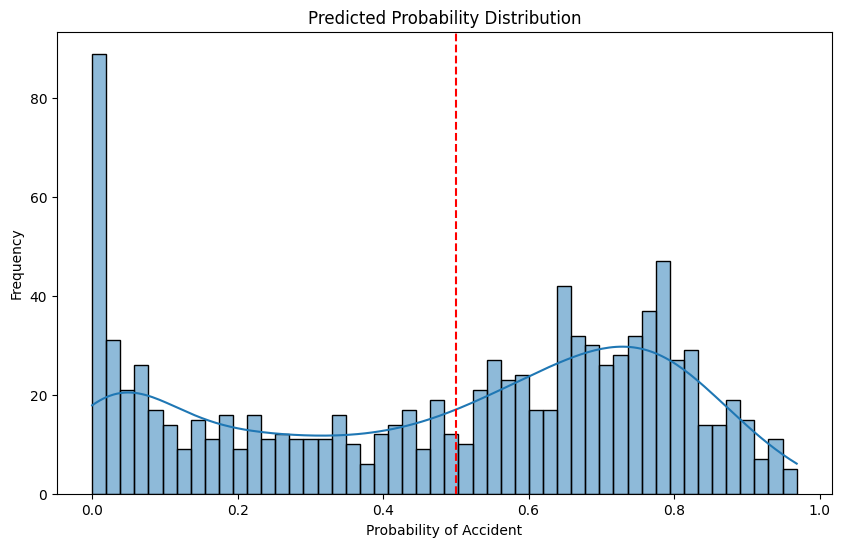

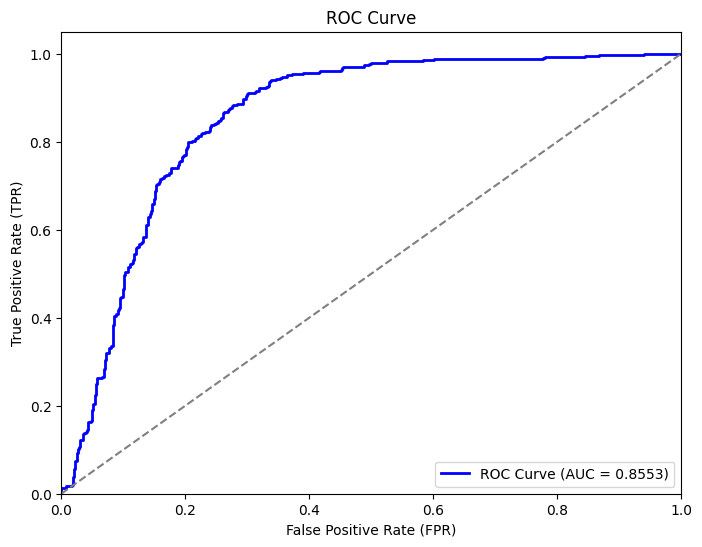

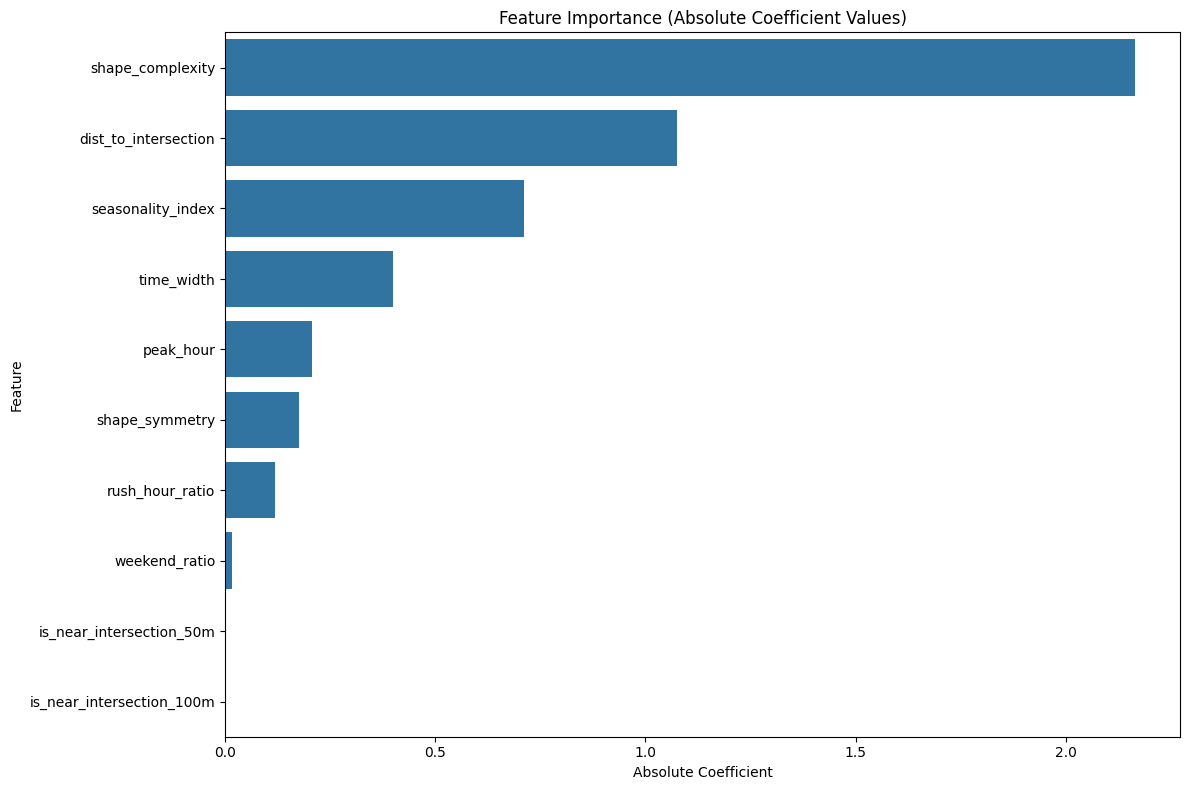

In [36]:
# 12. Predicted Probability Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_prob, bins=50, kde=True)
plt.title('Predicted Probability Distribution')
plt.xlabel('Probability of Accident')
plt.ylabel('Frequency')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.savefig('probability_distribution.png')

# 13. ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')

# 14. Feature Importance Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Abs_Coefficient', y='Feature', data=coef_df)
plt.title('Feature Importance (Absolute Coefficient Values)')
plt.xlabel('Absolute Coefficient')
plt.tight_layout()
plt.savefig('feature_importance.png')

# 15. Save Model Summary
results = {
    'Model': 'Logistic Regression',
    'AUC': roc_auc,
    'Number of Features': len(predictors),
    'Training Samples': len(X_train),
    'Test Samples': len(X_test),
    'Feature Importance': coef_df.to_dict(),
    'Intercept': logreg.intercept_[0]
}

# 16. Print Summary
print("\n=== Model Summary ===")
print("Model Type: Binary Logistic Regression")
print("Prediction Target: Whether a grid cell has an accident (has_accident)")
print(f"AUC Score: {roc_auc:.4f}")
print(f"Top 3 Most Important Features: {', '.join(coef_df['Feature'].head(3).tolist())}")
print("Conclusion: Based on the logistic regression model, we can effectively predict whether an accident will occur in a grid cell. The model achieved an AUC of {:.4f}".format(roc_auc))

'dist_to_intersection',  # 到交叉口的距离

'is_near_intersection_50m',  # 是否在交叉口50米范围内

'is_near_intersection_100m',  # 是否在交叉口100米范围内

'kde_density',  # KDE密度估计值

'density_ratio',  # 密度比率

'coverage_ratio',  # 覆盖率

'shape_symmetry',  # 形状对称性

'shape_complexity',  # 形状复杂度

'peak_hour',  # 高峰小时

'time_width',  # 时间宽度

'rush_hour_ratio',  # 高峰时段比例

'weekend_ratio',  # 周末比例

'seasonality_index'  # 季节性指数